# Notebook 6 — SHAP Explainability
**Karachi AQI Predictor — Model Transparency**

In [ ]:
# Install dependencies (run once)
# !pip install shap pandas numpy matplotlib joblib scikit-learn xgboost lightgbm

In [ ]:
import pandas as pd
import numpy as np
import joblib
import shap
import matplotlib.pyplot as plt
import warnings
from pathlib import Path
warnings.filterwarnings("ignore")

plt.rcParams.update({"figure.dpi": 110, "figure.facecolor": "white"})

ARTIFACT_PATH = "aqi_multioutput_model.pkl"
CSV_PATH      = "aqi_backfill_engineered.csv"
SHAP_DIR      = Path("shap_plots")
SHAP_DIR.mkdir(exist_ok=True)

N_BACKGROUND  = 500
N_EXPLAIN     = 1000
RANDOM_STATE  = 42

print("✅ Imports done")

✅ Imports done


## 1. Load Model Artifact & Data

In [ ]:
artifact   = joblib.load(ARTIFACT_PATH)
model      = artifact["model"]
feat_cols  = artifact["feature_cols"]
algo_name  = artifact.get("model_name", type(model).__name__)

print(f"Algorithm  : {algo_name}")
print(f"Features   : {len(feat_cols)}")
print(f"Target cols: {artifact.get('target_cols', ['D1','D2','D3'])}")

Algorithm  : Ridge
Features   : 55
Target cols: ['target_day1', 'target_day2', 'target_day3']


In [ ]:
df = pd.read_csv(CSV_PATH, parse_dates=["timestamp"])
df = df.sort_values("timestamp").reset_index(drop=True)

for c in feat_cols:
    if c not in df.columns:
        df[c] = 0.0
    df[c] = pd.to_numeric(df[c], errors="coerce").fillna(0.0)

X = df[feat_cols].dropna().reset_index(drop=True)
print(f"Rows available for SHAP: {len(X):,}")

Rows available for SHAP: 9,570


## 2. Build SHAP Explainer
Supports TreeExplainer (RF/XGB/LGB) and KernelExplainer (Ridge) automatically.

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.multioutput import MultiOutputRegressor

rng   = np.random.default_rng(RANDOM_STATE)
bg_idx = rng.choice(len(X), size=min(N_BACKGROUND, len(X)), replace=False)
X_bg   = X.iloc[bg_idx].reset_index(drop=True)

exp_idx = rng.choice(len(X), size=min(N_EXPLAIN, len(X)), replace=False)
X_exp   = X.iloc[exp_idx].reset_index(drop=True)

print(f"Background samples : {len(X_bg)}")
print(f"Explain samples    : {len(X_exp)}")

Background samples : 500
Explain samples    : 1000


In [ ]:
# Detects model type and builds appropriate explainer for each day
def get_base_estimator(model, day_idx):
    inner = model.named_steps["model"] if isinstance(model, Pipeline) else model
    if isinstance(inner, MultiOutputRegressor):
        return inner.estimators_[day_idx] if hasattr(inner, "estimators_") else inner
    return inner

def is_tree_model(estimator):
    name = type(estimator).__name__.lower()
    return any(k in name for k in ["forest","boost","tree","gbm","lgbm","xgb","gradient"])

# Build explainers and compute SHAP values for all 3 days
day_shap = {}
days     = ["Day 1 (0-24h)", "Day 2 (24-48h)", "Day 3 (48-72h)"]

inner = model.named_steps["model"] if isinstance(model, Pipeline) else model
scaler = model.named_steps.get("scaler", None) if isinstance(model, Pipeline) else None

for day_idx, day_name in enumerate(days):
    print(f"\n[{day_idx+1}/3] Computing SHAP for {day_name}...")
    base_est = get_base_estimator(model, day_idx)

    X_exp_t = scaler.transform(X_exp) if scaler else X_exp.values
    X_bg_t  = scaler.transform(X_bg)  if scaler else X_bg.values

    if is_tree_model(base_est):
        explainer = shap.TreeExplainer(base_est, data=X_bg_t)
        sv        = explainer.shap_values(X_exp_t)
        print(f"   ✅ TreeExplainer ({type(base_est).__name__})")
    else:
        # Fallback to KernelExplainer for linear models
        class SingleDay:
            def __init__(self, m, idx): self._m, self._idx = m, idx
            def predict(self, Xp): return np.clip(self._m.predict(Xp), 0, 500)[:, self._idx]
        explainer = shap.KernelExplainer(SingleDay(model, day_idx).predict,
                                         shap.sample(X_bg, 80))
        sv        = explainer.shap_values(X_exp.iloc[:200], nsamples=150)
        X_exp_t   = X_exp.iloc[:200].values
        print(f"   ✅ KernelExplainer")

    day_shap[day_name] = (sv, X_exp_t)

print("\n✅ All SHAP values computed")


[1/3] Computing SHAP for Day 1 (0-24h)...


  0%|          | 0/200 [00:00<?, ?it/s]

   ✅ KernelExplainer

[2/3] Computing SHAP for Day 2 (24-48h)...


  0%|          | 0/200 [00:00<?, ?it/s]

   ✅ KernelExplainer

[3/3] Computing SHAP for Day 3 (48-72h)...


  0%|          | 0/200 [00:00<?, ?it/s]

   ✅ KernelExplainer

✅ All SHAP values computed


## 3. Global Feature Importance — Mean |SHAP|

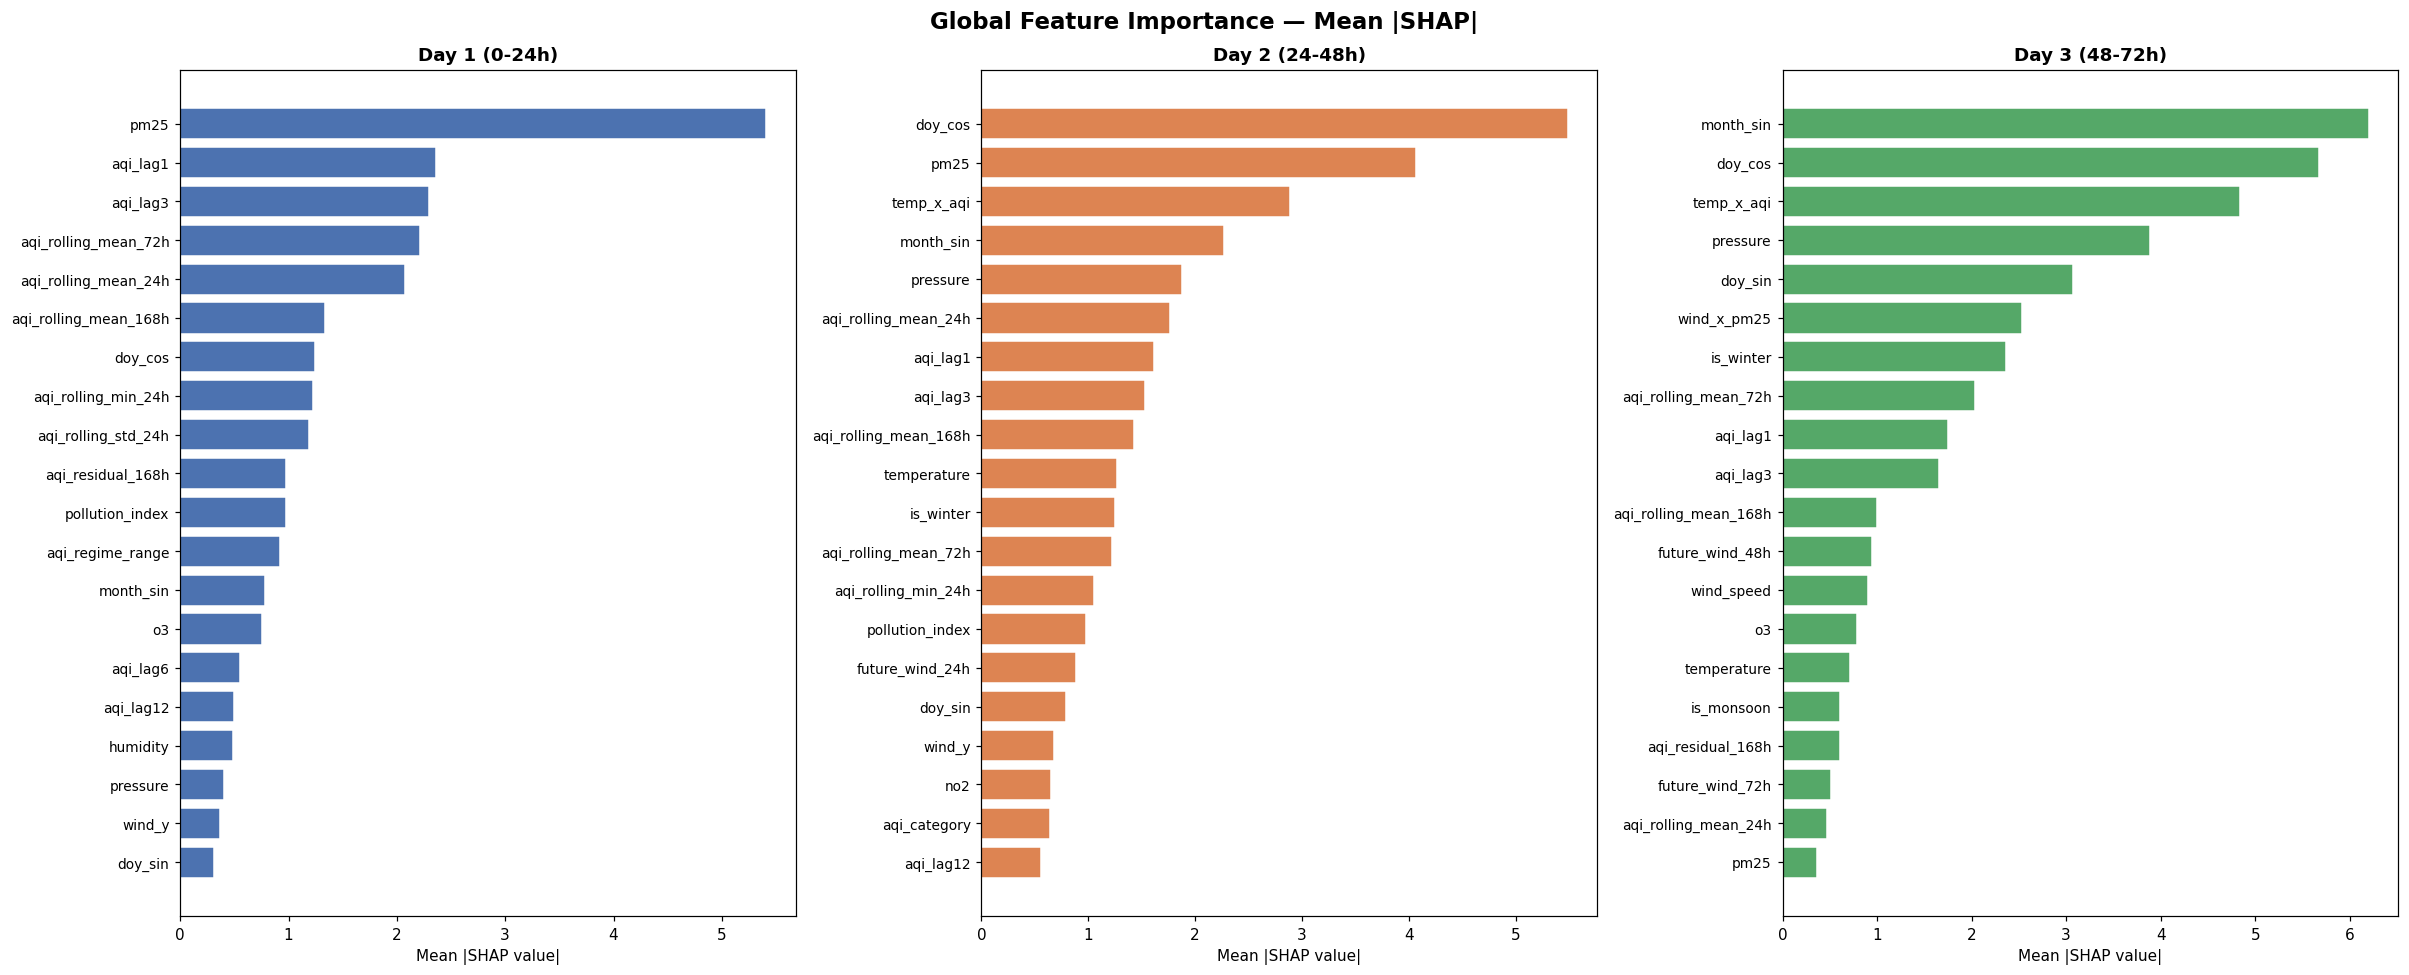

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(22, 9))
fig.suptitle("Global Feature Importance — Mean |SHAP|", fontsize=15, fontweight="bold")

colors = ["#4C72B0", "#DD8452", "#55A868"]
n_top  = 20

for ax, (day_name, color) in zip(axes, zip(days, colors)):
    sv, _ = day_shap[day_name]
    sv_arr = np.array(sv)
    if sv_arr.ndim == 1: sv_arr = sv_arr.reshape(1, -1)

    mean_abs = np.abs(sv_arr).mean(axis=0)
    cols_used = feat_cols if len(feat_cols) == len(mean_abs) else feat_cols[:len(mean_abs)]
    importance = pd.Series(mean_abs, index=cols_used).sort_values(ascending=True).tail(n_top)

    ax.barh(importance.index, importance.values, color=color, edgecolor="white")
    ax.set_title(day_name, fontsize=12, fontweight="bold")
    ax.set_xlabel("Mean |SHAP value|")
    ax.tick_params(axis="y", labelsize=9)

plt.tight_layout()
plt.savefig(SHAP_DIR / "01_global_importance.png", bbox_inches="tight")
plt.show()

## 4. SHAP Beeswarm Summary Plots

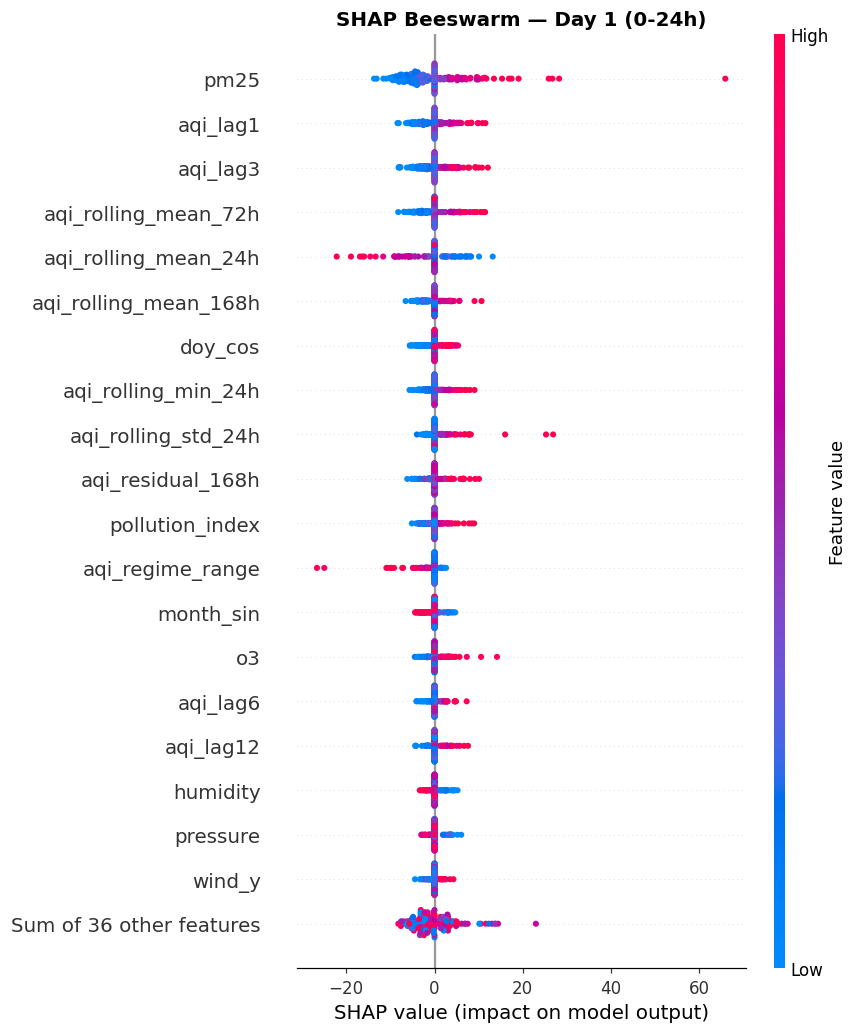

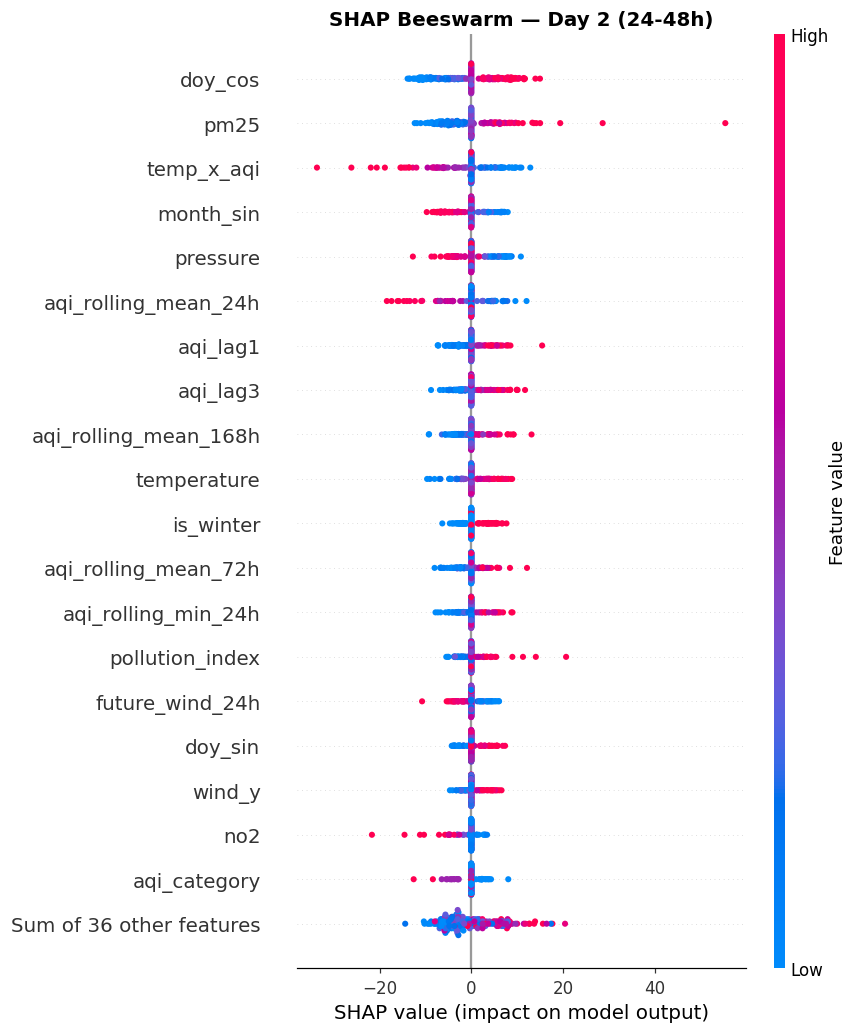

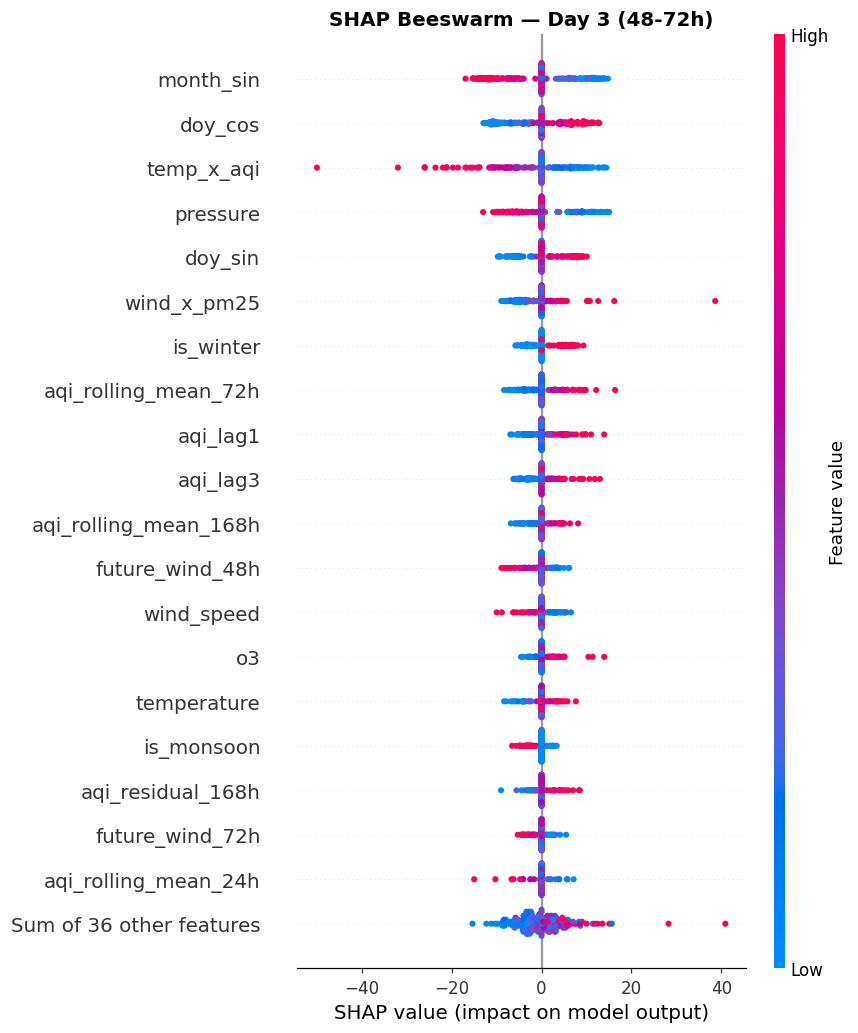

In [ ]:
for day_name in days:
    sv, X_vals = day_shap[day_name]
    sv_arr = np.array(sv)
    if sv_arr.ndim == 1: sv_arr = sv_arr.reshape(1, -1)

    cols_used = feat_cols if len(feat_cols) == sv_arr.shape[1] else feat_cols[:sv_arr.shape[1]]

    expl = shap.Explanation(values=sv_arr, data=X_vals, feature_names=cols_used)

    plt.figure(figsize=(10, 9))
    shap.plots.beeswarm(expl, max_display=20, show=False)
    plt.title(f"SHAP Beeswarm — {day_name}", fontsize=13, fontweight="bold")
    plt.tight_layout()
    safe = day_name.replace(" ","_").replace("(","").replace(")","").replace("-","")
    plt.savefig(SHAP_DIR / f"02_beeswarm_{safe}.png", bbox_inches="tight")
    plt.show()

## 5. SHAP Heatmap — Top 20 Features

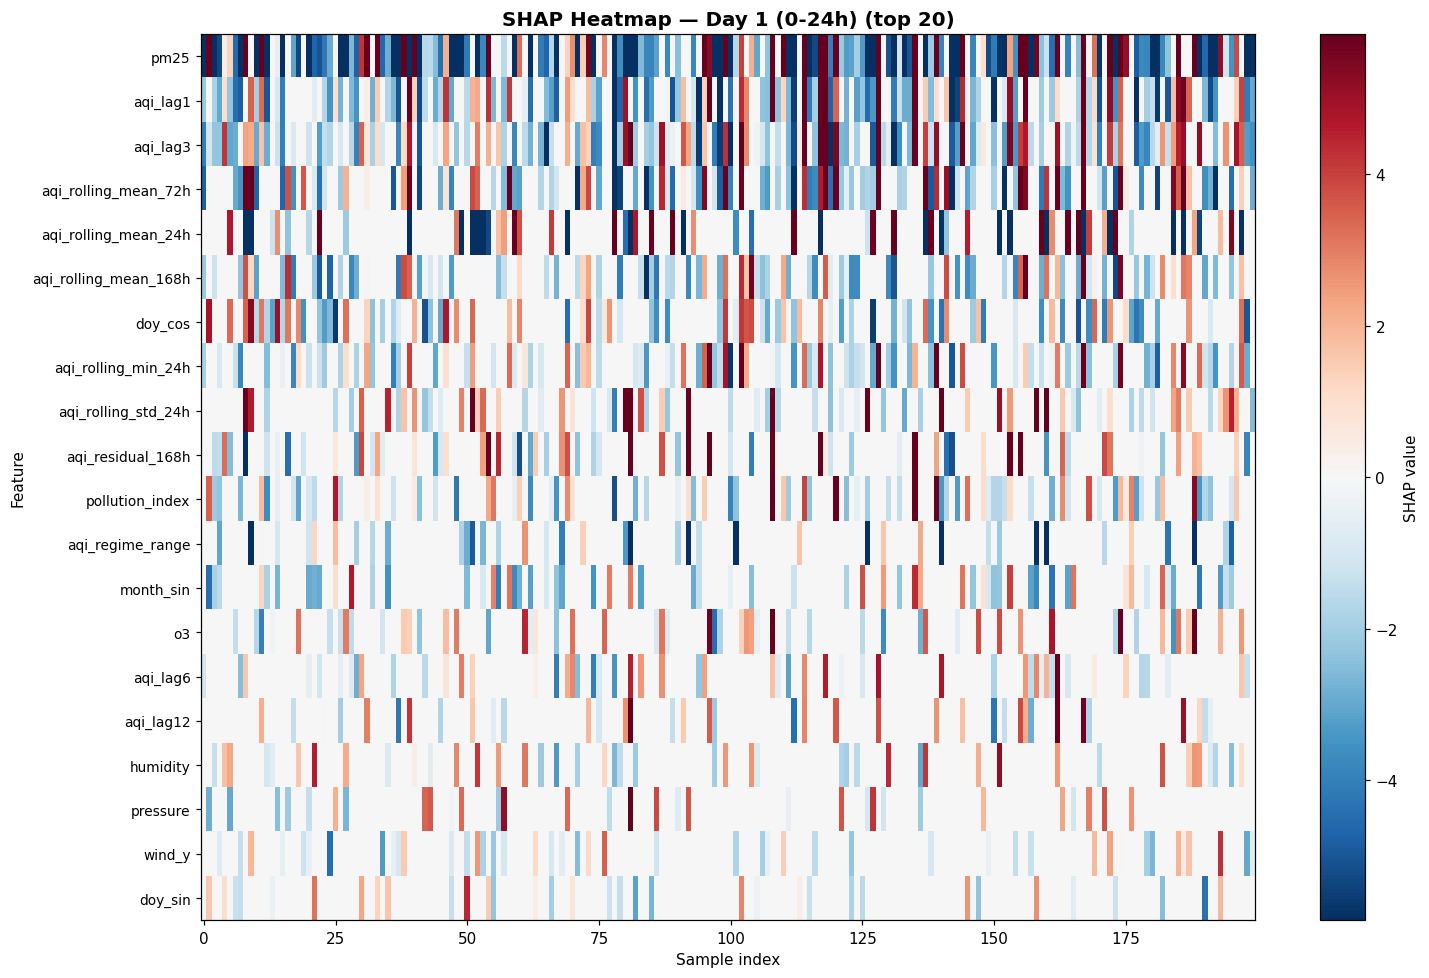

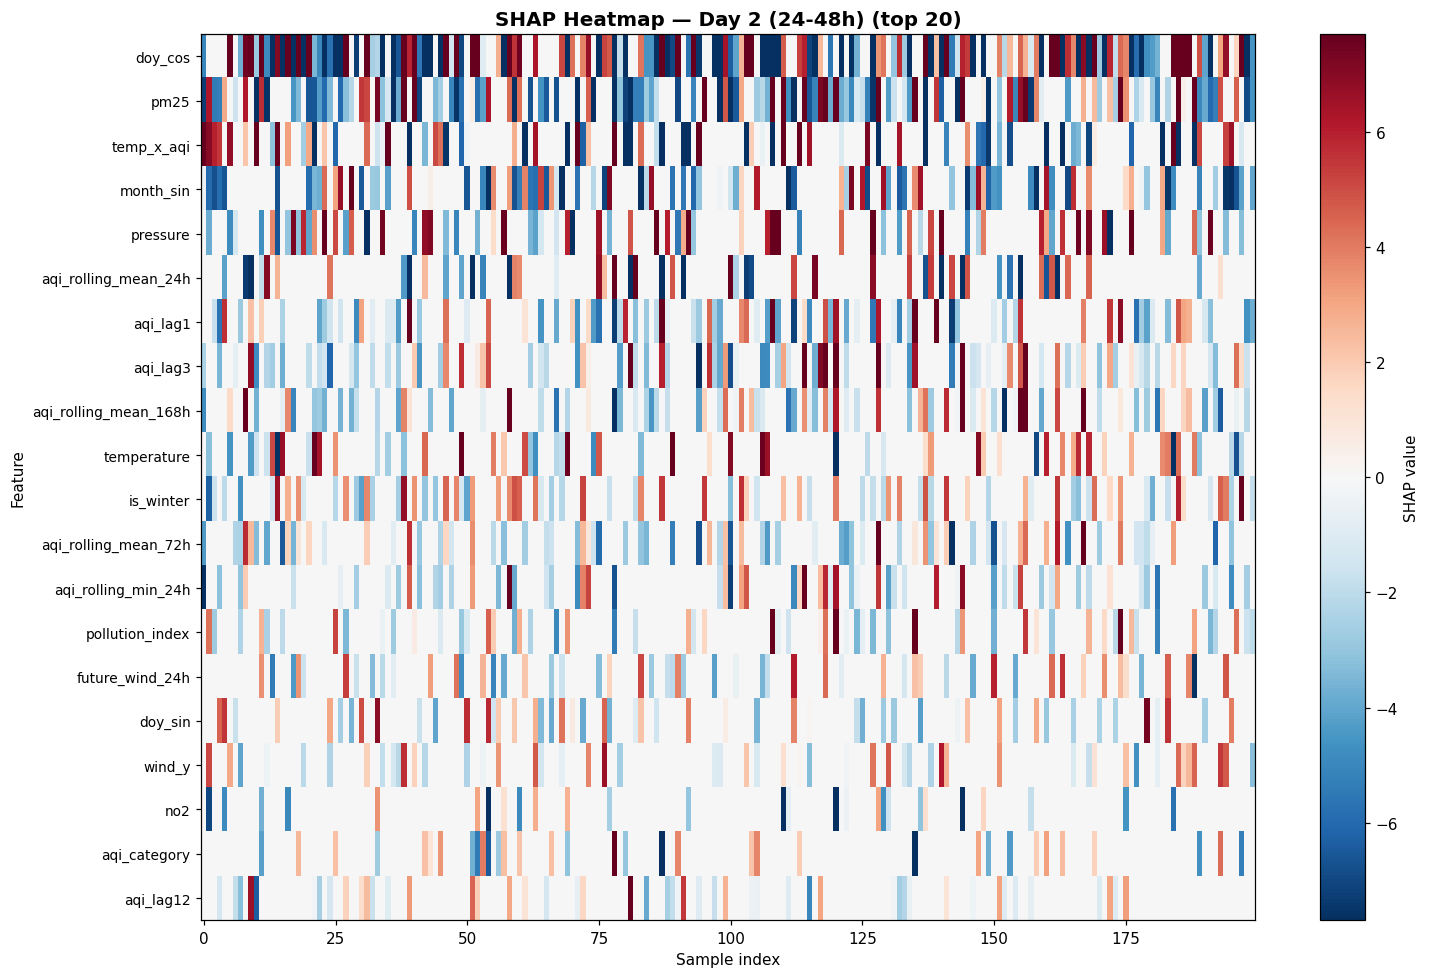

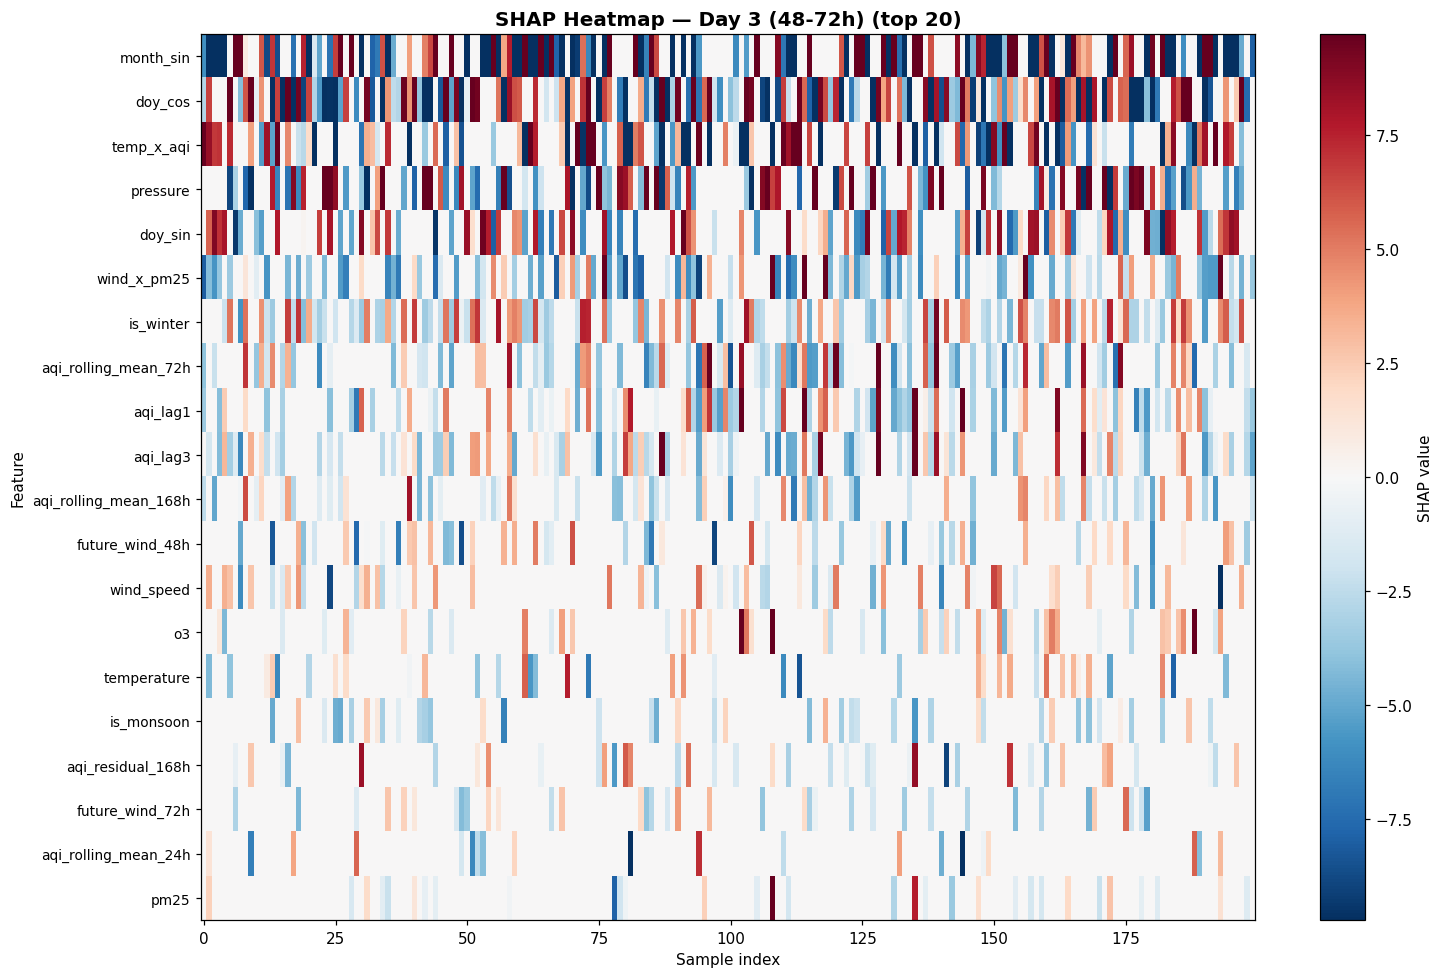

In [ ]:
for day_name in days:
    sv, X_vals = day_shap[day_name]
    sv_arr = np.array(sv)
    if sv_arr.ndim == 1: sv_arr = sv_arr.reshape(1, -1)

    cols_used = feat_cols if len(feat_cols) == sv_arr.shape[1] else feat_cols[:sv_arr.shape[1]]
    top20_idx = np.argsort(np.abs(sv_arr).mean(axis=0))[::-1][:20]
    top_cols  = [cols_used[i] for i in top20_idx]
    sv_top    = sv_arr[:min(300, len(sv_arr)), :][:, top20_idx]

    vmax = np.percentile(np.abs(sv_top), 95)
    fig, ax = plt.subplots(figsize=(14, 9))
    im = ax.imshow(sv_top.T, aspect="auto", cmap="RdBu_r", vmin=-vmax, vmax=vmax)
    ax.set_yticks(range(len(top_cols))); ax.set_yticklabels(top_cols, fontsize=9)
    ax.set_xlabel("Sample index"); ax.set_ylabel("Feature")
    ax.set_title(f"SHAP Heatmap — {day_name} (top 20)", fontsize=13, fontweight="bold")
    plt.colorbar(im, ax=ax, label="SHAP value")
    plt.tight_layout()
    safe = day_name.replace(" ","_").replace("(","").replace(")","").replace("-","")
    plt.savefig(SHAP_DIR / f"03_heatmap_{safe}.png", bbox_inches="tight")
    plt.show()

## 6. Dependence Plots — Top 5 Features

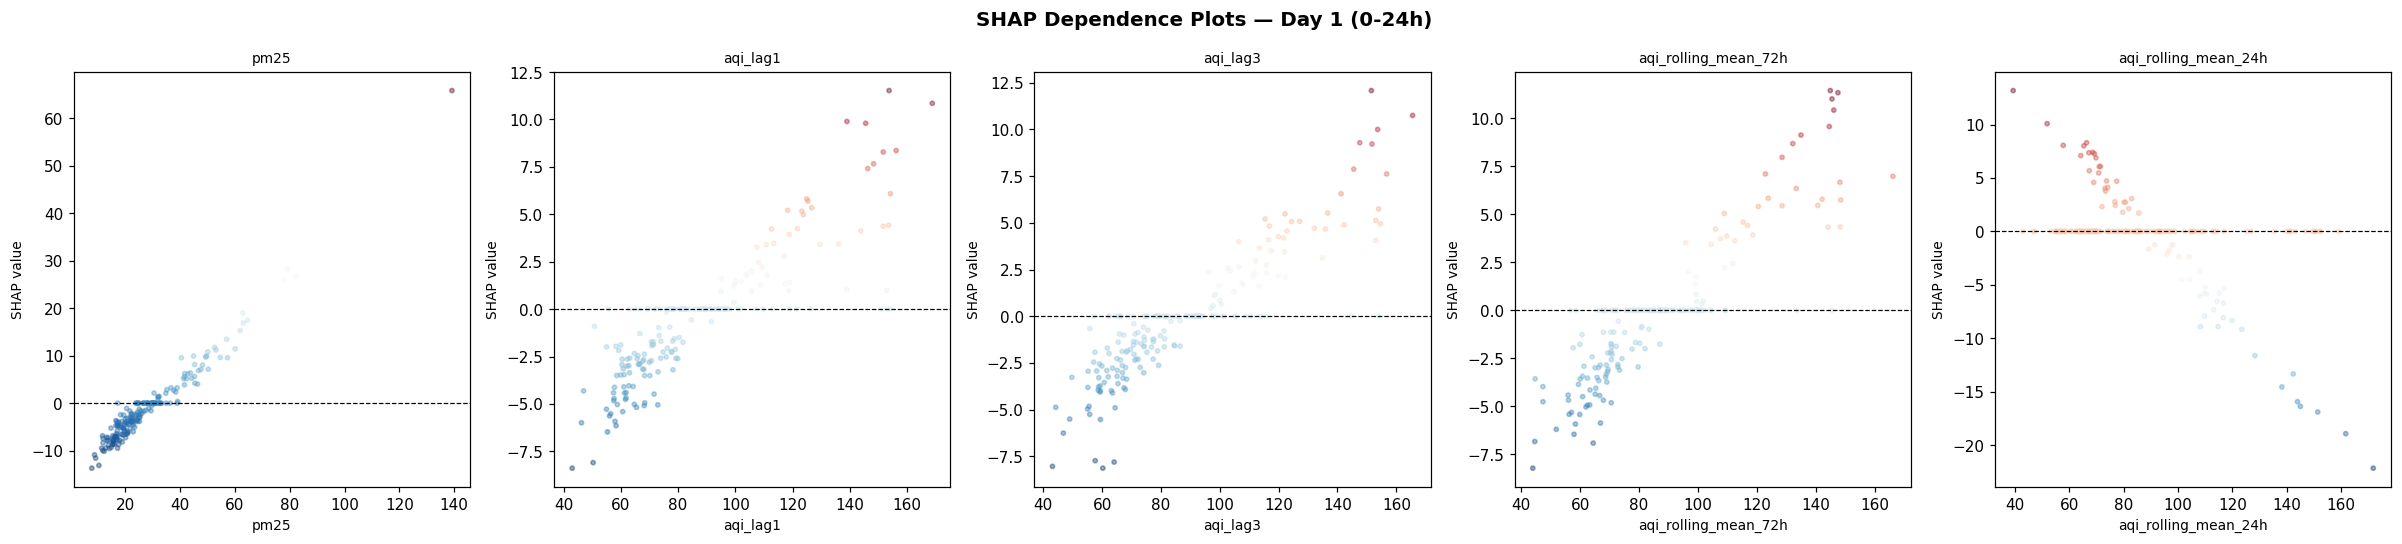

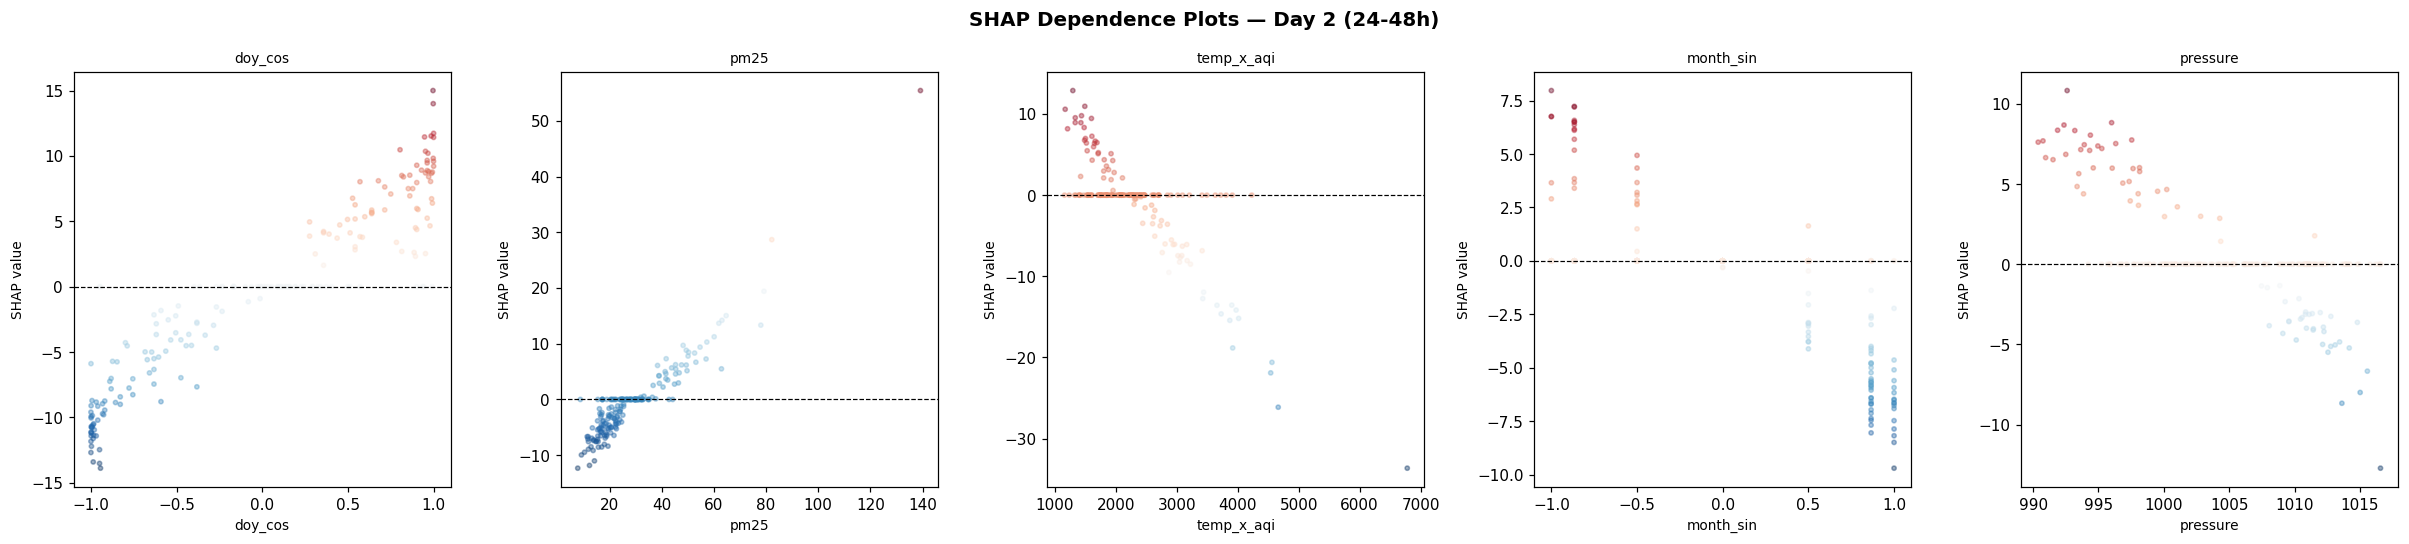

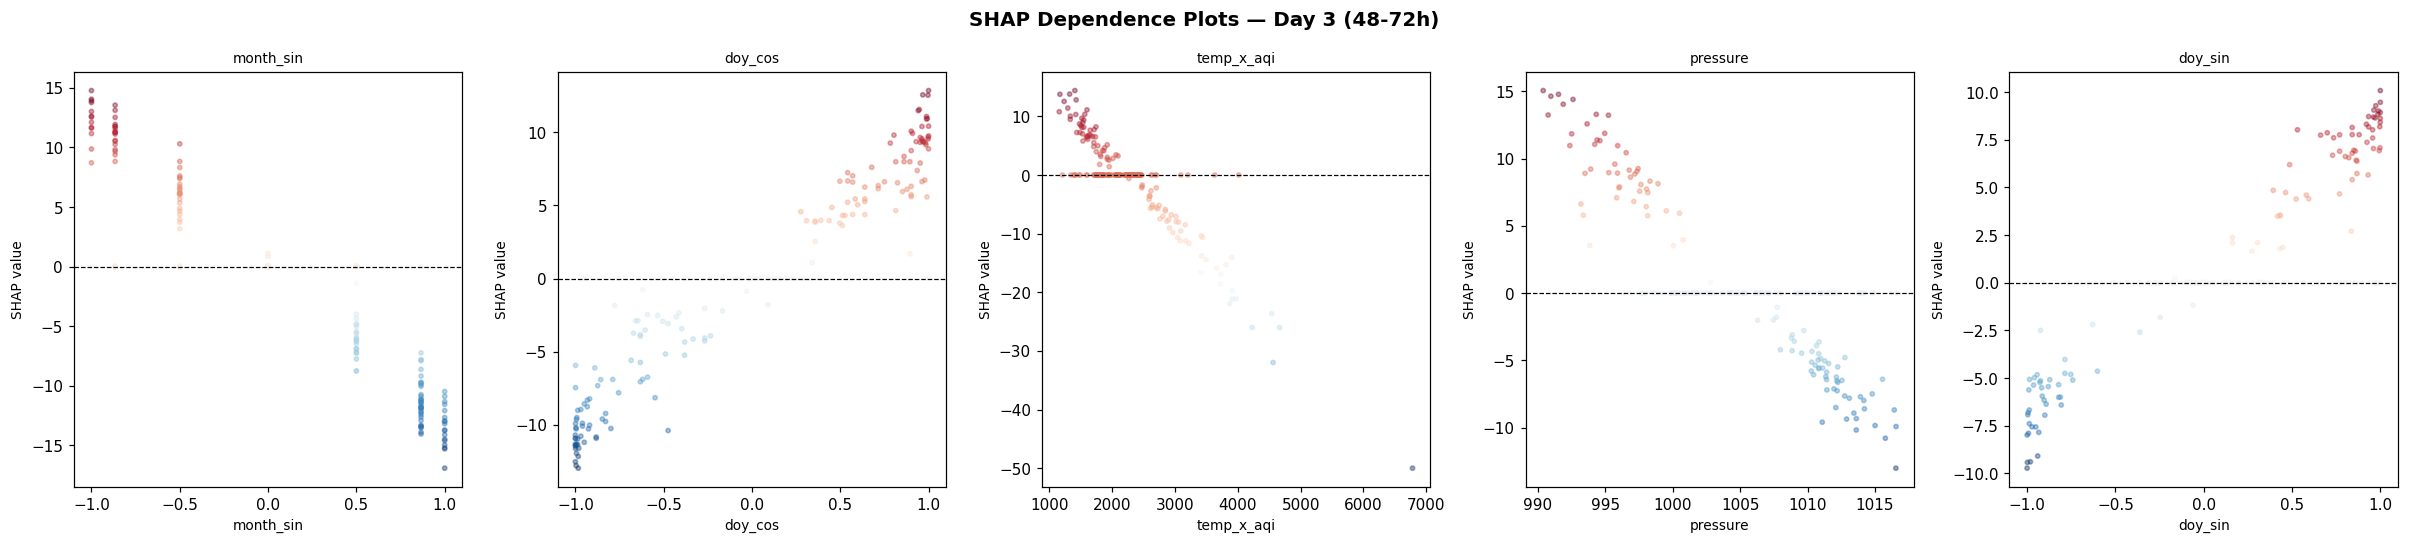

In [ ]:
for day_name in days:
    sv, X_vals = day_shap[day_name]
    sv_arr  = np.array(sv)
    if sv_arr.ndim == 1: sv_arr = sv_arr.reshape(1, -1)

    cols_used = feat_cols if len(feat_cols) == sv_arr.shape[1] else feat_cols[:sv_arr.shape[1]]
    top5_idx  = np.argsort(np.abs(sv_arr).mean(axis=0))[::-1][:5]
    top5_cols = [cols_used[i] for i in top5_idx]

    fig, axes = plt.subplots(1, 5, figsize=(22, 5))
    fig.suptitle(f"SHAP Dependence Plots — {day_name}", fontsize=13, fontweight="bold")

    for ax, feat_idx, feat_name in zip(axes, top5_idx, top5_cols):
        feat_vals = X_vals[:, feat_idx]
        shap_v    = sv_arr[:, feat_idx]
        ax.scatter(feat_vals, shap_v, s=8, alpha=0.4, c=shap_v, cmap="RdBu_r")
        ax.axhline(0, color="black", lw=0.8, ls="--")
        ax.set_xlabel(feat_name, fontsize=9); ax.set_ylabel("SHAP value", fontsize=9)
        ax.set_title(feat_name, fontsize=9)

    plt.tight_layout()
    safe = day_name.replace(" ","_").replace("(","").replace(")","").replace("-","")
    plt.savefig(SHAP_DIR / f"04_dependence_{safe}.png", bbox_inches="tight")
    plt.show()

## 7. Waterfall Plot — Single Prediction Explanation

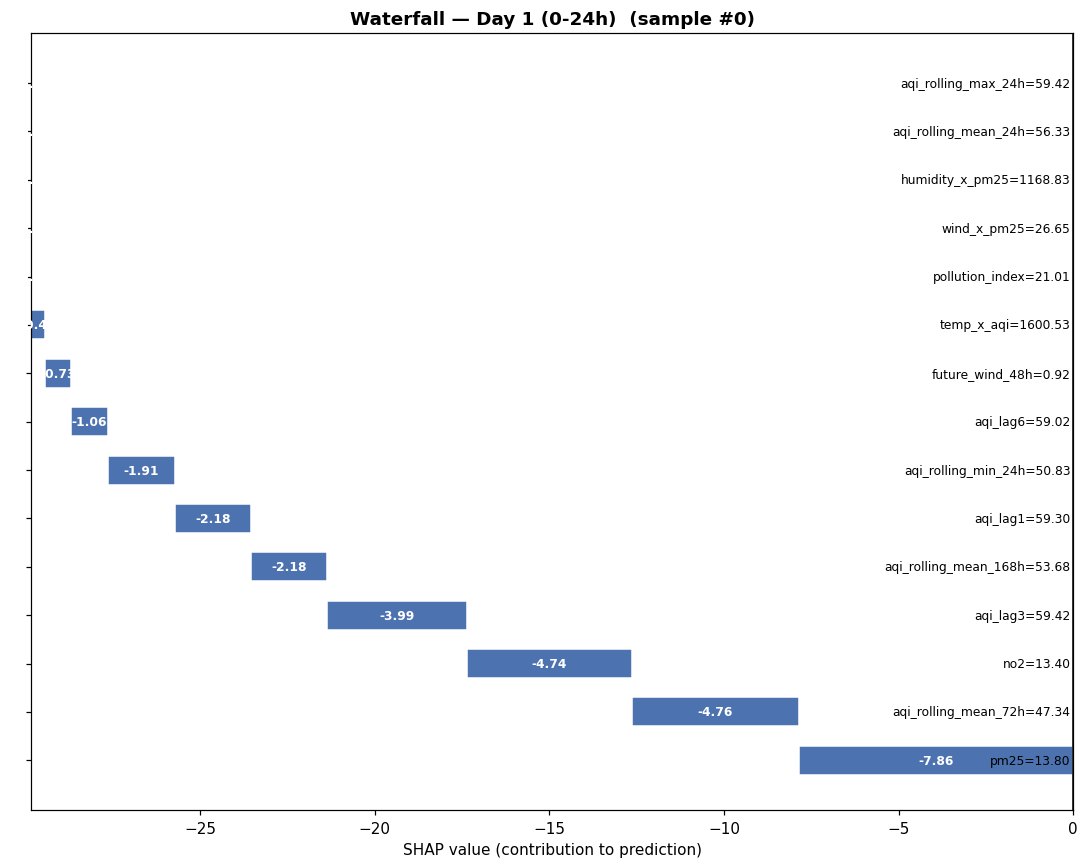

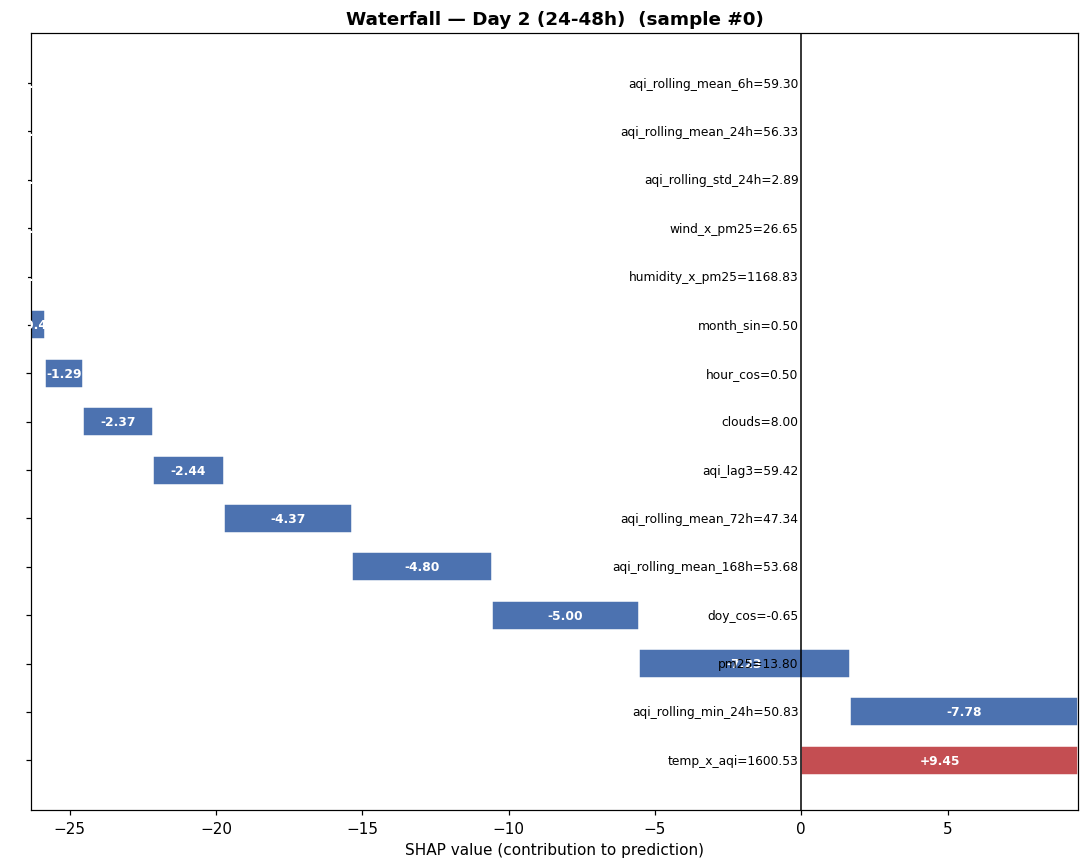

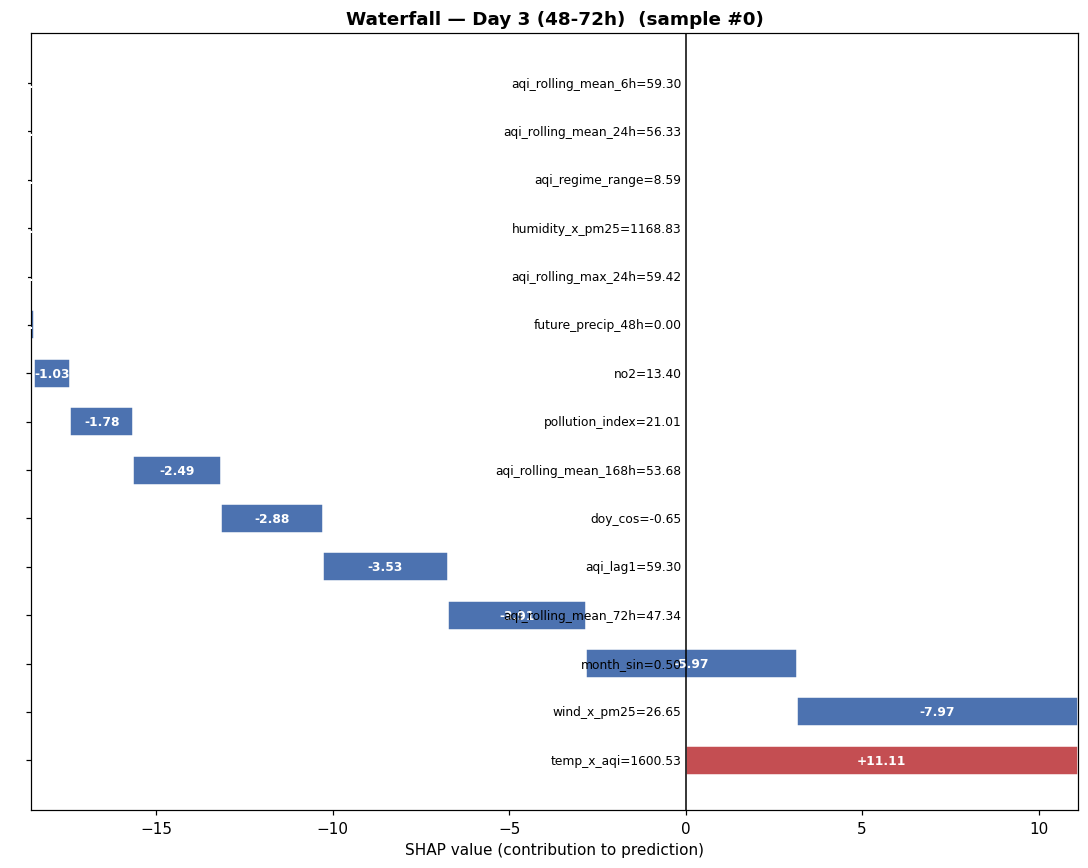

In [ ]:
# Change sample_idx to explain a different prediction
sample_idx = 0

for day_name in days:
    sv, X_vals = day_shap[day_name]
    sv_arr  = np.array(sv)
    if sv_arr.ndim == 1: sv_arr = sv_arr.reshape(1, -1)

    cols_used = feat_cols if len(feat_cols) == sv_arr.shape[1] else feat_cols[:sv_arr.shape[1]]
    idx       = min(sample_idx, len(sv_arr) - 1)
    sv_row    = sv_arr[idx]
    X_row     = X_vals[idx]

    top15_idx  = np.argsort(np.abs(sv_row))[::-1][:15]
    top_feats  = [cols_used[i] for i in top15_idx]
    top_sv     = sv_row[top15_idx]
    top_vals   = X_row[top15_idx]

    fig, ax = plt.subplots(figsize=(10, 8))
    colors_bar = ["#C44E52" if v > 0 else "#4C72B0" for v in top_sv]
    cumulative = 0
    for i, (feat, sv_val, feat_val) in enumerate(zip(top_feats, top_sv, top_vals)):
        ax.barh(i, sv_val, left=cumulative, color=colors_bar[i], edgecolor="white", height=0.6)
        ax.text(cumulative + sv_val/2, i, f"{sv_val:+.2f}", va="center", ha="center",
                fontsize=8, color="white", fontweight="bold")
        ax.text(-0.01*max(np.abs(top_sv)), i, f"{feat}={feat_val:.2f}",
                va="center", ha="right", fontsize=8)
        cumulative += sv_val

    ax.set_yticks(range(len(top_feats))); ax.set_yticklabels([""]*len(top_feats))
    ax.set_xlabel("SHAP value (contribution to prediction)")
    ax.set_title(f"Waterfall — {day_name}  (sample #{idx})", fontsize=12, fontweight="bold")
    ax.axvline(0, color="black", lw=1)
    plt.tight_layout()
    safe = day_name.replace(" ","_").replace("(","").replace(")","").replace("-","")
    plt.savefig(SHAP_DIR / f"05_waterfall_{safe}.png", bbox_inches="tight")
    plt.show()

## 8. Feature Importance Summary Table

In [ ]:
print("="*65)
print("TOP 15 FEATURES BY MEAN |SHAP| — ALL DAYS")
print("="*65)
print(f"{'Feature':<30} {'Day1':>8} {'Day2':>8} {'Day3':>8}  {'Avg':>8}")
print("-"*65)

results = {}
for day_name in days:
    sv, _ = day_shap[day_name]
    sv_arr = np.array(sv)
    if sv_arr.ndim == 1: sv_arr = sv_arr.reshape(1, -1)
    cols_used = feat_cols if len(feat_cols) == sv_arr.shape[1] else feat_cols[:sv_arr.shape[1]]
    results[day_name] = pd.Series(np.abs(sv_arr).mean(axis=0), index=cols_used)

all_feats = results[days[0]].index
combined  = pd.DataFrame({d: results[d] for d in days})
combined["avg"] = combined.mean(axis=1)
top15 = combined.sort_values("avg", ascending=False).head(15)

for feat, row in top15.iterrows():
    print(f"  {feat:<30} {row[days[0]]:>8.3f} {row[days[1]]:>8.3f} {row[days[2]]:>8.3f}  {row['avg']:>8.3f}")

print("\n✅ All SHAP plots saved to: shap_plots/")

TOP 15 FEATURES BY MEAN |SHAP| — ALL DAYS
Feature                            Day1     Day2     Day3       Avg
-----------------------------------------------------------------
  doy_cos                           1.245    5.485    5.673     4.134
  pm25                              5.411    4.069    0.364     3.281
  month_sin                         0.783    2.271    6.200     3.085
  temp_x_aqi                        0.060    2.887    4.839     2.596
  pressure                          0.403    1.882    3.887     2.057
  aqi_lag1                          2.363    1.615    1.752     1.910
  aqi_lag3                          2.295    1.534    1.657     1.829
  aqi_rolling_mean_72h              2.210    1.220    2.039     1.823
  aqi_rolling_mean_24h              2.079    1.768    0.466     1.438
  doy_sin                           0.308    0.793    3.073     1.392
  aqi_rolling_mean_168h             1.334    1.425    0.998     1.252
  is_winter                         0.134    1.253    